In [12]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KernelDensity
from scipy import stats
from scipy.stats import linregress

import time

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'daiys'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds



def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def weighted(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

In [3]:

#read in files
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'
t2m = decode_time(fp).sel(time = slice('1950', '2023'), lat = slice(20, -20))

fp = '/data/jmex/output/drivers/indices/nino.nc'
nino = xr.open_dataset(fp)

fp = '/data/jmex/output/drivers/indices/indices.nc'
indices = xr.open_dataset(fp)

In [4]:
#compute nino34 OND index
ninoOND = nino.where(nino.time.dt.month.isin([10,11,12])).groupby('time.year').mean().nino34
nino34 = ninoOND/ninoOND.std()

In [5]:
#compute monthly values (area averaged)
tweights = np.cos(np.deg2rad(t2m.lat))
#global annual temp
t2m = t2m.weighted(tweights).mean(['lat', 'lon']).groupby('time.year').mean().t2m

In [6]:
#caluclate temperature difference betweeen consecutive years
dt2m = t2m - t2m.roll(year = 1)

dt2m = dt2m.sel(year = slice('1958','2023'))
dt2m = dt2m/dt2m.std()


In [7]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp).sel(time = slice('1958', '2023'))

#compute monthly values (area averaged)
tp_weights = np.cos(np.deg2rad(tp.lat))
#selct west area
tp_west = tp.sel(lat = slice(20, -20), lon = slice(130,150))
tp_west_mean = tp_west.weighted(tp_weights).mean(['lat', 'lon'])

tp = tp_west_mean.groupby('time.year').mean().tp
tp = tp - tp.mean()
tp = tp/tp.std()

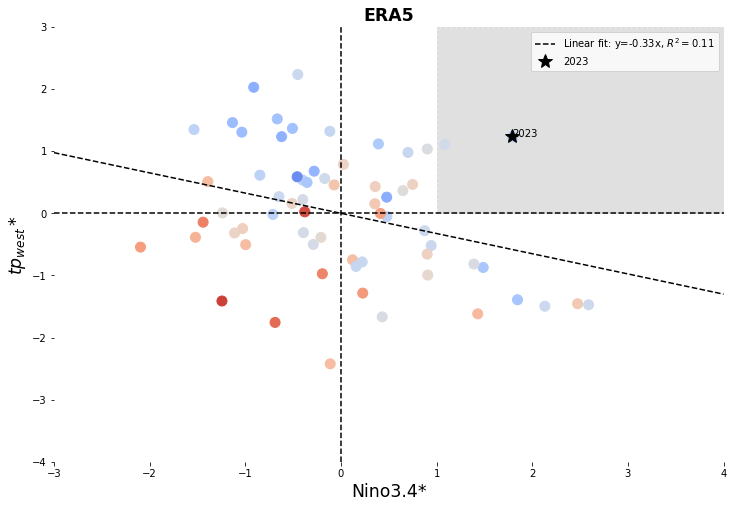

In [30]:
fig, ax = plt.subplots(1,1, figsize = (12,8))

ax.set_ylim(-4, 3)
ax.set_xlim(-3, 4)
ax.set_ylabel(r'$tp_{west}*$', fontsize = 'xx-large')
ax.set_xlabel(r'Nino3.4*', fontweight='normal', fontsize = 'xx-large')
ax.set_title('ERA5')

ax.axhline(0, linestyle='--', c='k')
ax.axvline(0, linestyle='--', c='k')

# Define the coordinates and dimensions of the shaded area
x_min, x_max = 1, 4
y_min, y_max = 0, 3

# Shade the rectangular area
ax.fill_betweenx(y=[y_min, y_max], x1=x_min, x2=x_max, color='lightgrey', alpha=0.7, linestyle='--')




ax.text(y = tp.sel(year = 2023), x = nino34.data[-1], s = '2023')
#ax.text(y = tp.sel(year = 2009), x = nino34.data[-15], s = '2009')

# Hide all spines
for spine in ax.spines.values():
    spine.set_visible(False)
    
# Fit a regression line to the collected points
slope, intercept, r_value, p_value, std_err = linregress(y = tp, x = nino34)

# Plot the regression line
x_vals = np.array(ax.get_xlim())
y_vals = intercept + slope * x_vals
ax.plot(x_vals, y_vals, '--', color='k', label=f'Linear fit: y={slope:.2f}x, $R^2={r_value**2:.2f}$')

ax.plot(1.79, 1.25, marker='*', color='black', markersize=15, label = '2023', linestyle = ' ')



cmap = ax.scatter(y = tp, x = nino34, c = nino34.roll(year = 1), cmap = 'coolwarm', s= 100, vmin = -3, vmax = 3)

#for i in range(1,len(dt2m.t2m)):
 #   plt.arrow(y = tp_cumsept.isel(year = i).tp, x = ninoOND.isel(year = i).nino34, 
  #            dy =-(tp_cumsept.isel(year = i)-tp_cumsept.isel(year = (i-1))).tp/10,
   #           dx = -(ninoOND.isel(year=i).nino34-ninoOND.isel(year=(i-1)).nino34)/10)
#fig.colorbar(cmap, label = r'Δ TAS' ,use_gridspec = True)
ax.legend()

plt.show()


In [9]:
print(tp.sel(year = 2023), nino34.data[-1])


1.23, 1.80

Text(1.7953512710955113, <xarray.DataArray 'tp' ()>
array(1.23411179)
Coordinates:
    year     int64 2023, '2023')

In [20]:
ax.plot(1.23, 1.8, marker='*', color='black', markersize=15)


In [35]:
t2m.t2m

<xarray.DataArray 't2m' (year: 74)>
array([298.13208809, 298.30574264, 298.37090017, 298.36137664,
       298.12733635, 297.98059261, 297.91227218, 298.30817409,
       298.529129  , 298.40784744, 298.34887915, 298.35795274,
       298.22036905, 298.37644486, 298.24879071, 298.2858018 ,
       298.51905439, 298.23971406, 298.20630936, 298.58637612,
       298.39998805, 298.03338695, 298.37549453, 298.51731229,
       298.04502409, 298.03641803, 298.0665549 , 298.37444781,
       298.34213795, 298.50113146, 298.56994548, 298.40555867,
       298.48017996, 298.71293172, 298.35247994, 298.2713056 ,
       298.40227812, 298.80315463, 298.66620365, 298.32607735,
       298.63595884, 298.63937354, 298.52970499, 298.57462833,
       298.55727162, 298.68672264, 298.56607906, 298.74058503,
       299.08509042, 298.45069375, 298.46739728, 298.61239293,
       298.79415867, 298.84143323, 298.74179423, 298.88345866,
       298.77543425, 298.7417012 , 298.57362161, 298.87458027,
       298.99645081, 298.60513966, 298.73595455, 298.86310248,
       298.88670677, 299.11319014, 299.27947099, 299.04609411,
       298.88966829, 299.13425719, 299.11477156, 298.92127496,
       298.80809428, 299.24474112])
Coordinates:
  * year     (year) int64 1950 1951 1952 1953 1954 ... 2019 2020 2021 2022 2023

## comments
does not matter much if taken ASO or Jan-Dec or any other for both Cum precip and dT.
in both cases the 2023 and 2009 ones stand out and are in a box of large NINO34 paired with large precip, where there is usually few things. 



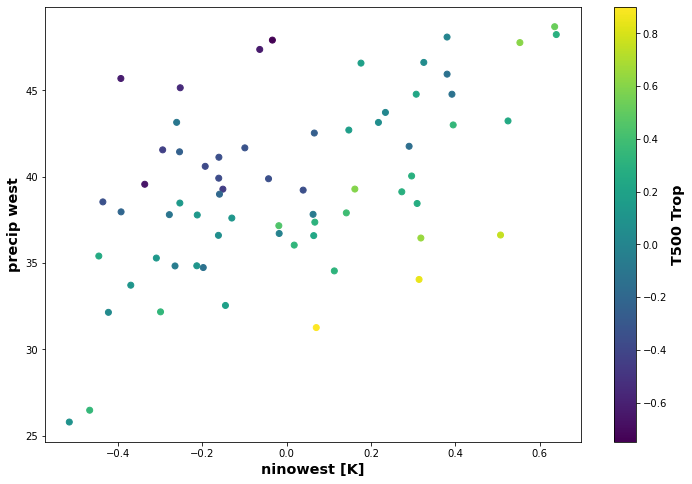

In [43]:
plt.figure(figsize = (12,8))

plt.scatter(nino.resample(time = '1Y').mean().ninowest, tp_cumsept.tp, c = t500_trop_anom.resample(time = '1Y').mean().t)

plt.xlabel('ninowest [K]')
plt.ylabel('precip west')
plt.colorbar(label ='T500 Trop');

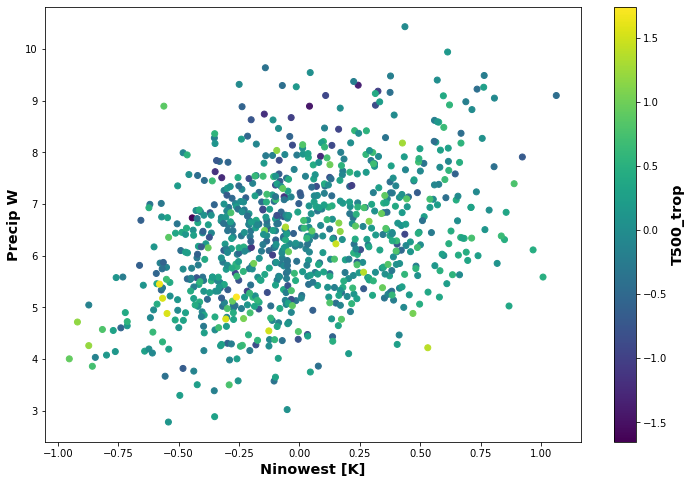

In [115]:
plt.figure(figsize = (12,8))
plt.scatter(nino.ninowest, tp_west.sel(time = slice('1958', '2023')).tp, c = t500_trop_anom.t)

plt.xlabel('Ninowest [K]')
plt.ylabel('Precip W')
plt.colorbar(label = 'T500_trop')

## Combination of Precip in Areas

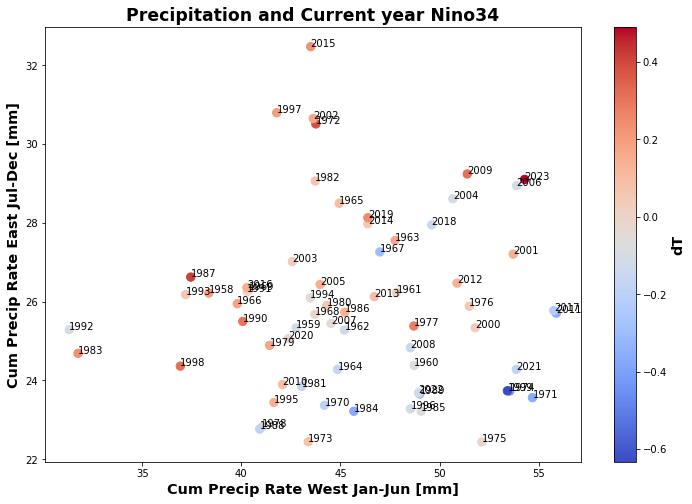

In [52]:
#extract the times of interest
t2m_oct = t2m.where(t2m.time.dt.month > 1, drop = True).resample(time = '1Y').mean()

tp_cumeast = tp_east.where((tp_east.time.dt.month>=7)&(tp_east.time.dt.month<=12), drop = True).groupby('time.year').sum()
tp_cumwest = tp_west.where(tp_west.time.dt.month<=7, drop = True).groupby('time.year').sum()

#caluclate temperature difference betweeen consecutive years
dt2m_oct = t2m_oct - t2m_oct.roll(time = 1)

#take of first value each, as not valid
dt2m_oct = dt2m_oct.sel(time = slice('1958','2023'))
tp_cumwest = tp_cumwest.sel(year = slice('1958','2023'))
tp_cumeast = tp_cumeast.sel(year = slice('1958','2023'))


fig, ax = plt.subplots(1,1, figsize = (12,8))

ax.set_xlabel('Cum Precip Rate West Jan-Jun [mm]')
ax.set_ylabel('Cum Precip Rate East Jul-Dec [mm]')
ax.set_title('Precipitation and Current year Nino34')

for i in range(tp_cumwest.year.shape[0]):
    ax.text(x = tp_cumwest.tp.isel(year = i), y = tp_cumeast.tp.isel(year = i), s = tp_cumeast.isel(year = i).year.data)
cmap = ax.scatter(tp_cumwest.tp, tp_cumeast.tp, c= dt2m_oct.t2m, 
                  cmap = 'coolwarm', s= 70)
fig.colorbar(cmap, label = 'dT')
plt.show()

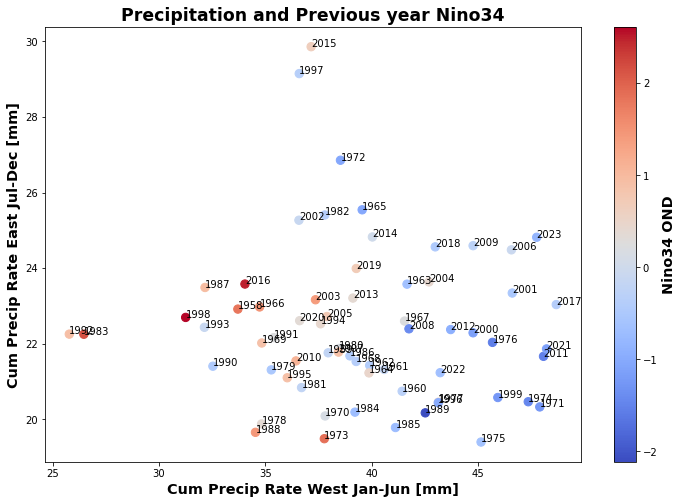

In [12]:
#extract the times of interest
t2m_oct = t2m.where(t2m.time.dt.month > 6, drop = True).resample(time = '1Y').mean()

tp_cumeast = tp_east.where((tp_east.time.dt.month>=7)&(tp_east.time.dt.month<=12), drop = True).groupby('time.year').sum()
tp_cumwest = tp_west.where(tp_west.time.dt.month<=6, drop = True).groupby('time.year').sum()

#caluclate temperature difference betweeen consecutive years
dt2m_oct = t2m_oct - t2m_oct.roll(time = 1)

#take of first value each, as not valid
dt2m_oct = dt2m_oct.sel(time = slice('1958','2023'))
tp_cumwest = tp_cumwest.sel(year = slice('1958','2023'))
tp_cumeast = tp_cumeast.sel(year = slice('1958','2023'))


fig, ax = plt.subplots(1,1, figsize = (12,8))

ax.set_xlabel('Cum Precip Rate West Jan-Jun [mm]')
ax.set_ylabel('Cum Precip Rate East Jul-Dec [mm]')
ax.set_title('Precipitation and Previous year Nino34')

for i in range(tp_cumwest.year.shape[0]):
    ax.text(x = tp_cumwest.tp.isel(year = i), y = tp_cumeast.tp.isel(year = i), s = tp_cumeast.isel(year = i).year.data)
cmap = ax.scatter(tp_cumwest.tp, tp_cumeast.tp, c= ninoOND.nino34.roll(year = 1), 
                  cmap = 'coolwarm', s= 70)
fig.colorbar(cmap, label = 'Nino34 OND')
plt.show()

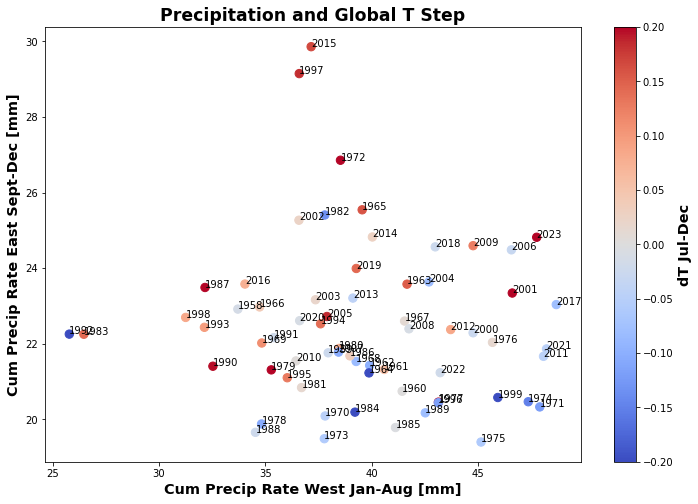

In [13]:
#extract the times of interest
t2m_oct = t2m.where(t2m.time.dt.month > 6, drop = True).resample(time = '1Y').mean()

tp_cumeast = tp_east.where((tp_east.time.dt.month>6)&(tp_east.time.dt.month<=12), drop = True).groupby('time.year').sum()
tp_cumwest = tp_west.where(tp_west.time.dt.month<=6, drop = True).groupby('time.year').sum()

#caluclate temperature difference betweeen consecutive years
dt2m_oct = t2m_oct - t2m_oct.roll(time = 1)

#take of first value each, as not valid
dt2m_oct = dt2m_oct.sel(time = slice('1958','2023'))
tp_cumwest = tp_cumwest.sel(year = slice('1958','2023'))
tp_cumeast = tp_cumeast.sel(year = slice('1958','2023'))


fig, ax = plt.subplots(1,1, figsize = (12,8))

ax.set_xlabel('Cum Precip Rate West Jan-Aug [mm]')
ax.set_ylabel('Cum Precip Rate East Sept-Dec [mm]')
ax.set_title('Precipitation and Global T Step')

for i in range(tp_cumwest.year.shape[0]):
    ax.text(x = tp_cumwest.tp.isel(year = i), y = tp_cumeast.tp.isel(year = i), s = tp_cumeast.isel(year = i).year.data)
cmap = ax.scatter(tp_cumwest.tp, tp_cumeast.tp, c= dt2m_oct.t2m, 
                  cmap = 'coolwarm', vmin = -0.2, vmax = 0.2, s= 70)
fig.colorbar(cmap, label = 'dT Jul-Dec')
plt.show()

In [38]:
fp = '/data/jmex/ERA5/monthly/era5_t500.nc'
t500 = decode_time(fp)
weights = np.cos(np.deg2rad(t500.lat))
#t500_glb = t500.weighted(weights).mean(['lat','lon'])

In [132]:
t500_glb_anom = t500_glb.groupby('time.month') - t500_glb.groupby('time.month').mean()

In [109]:
t500_trop = t500.sel(lat = slice(20,-20), lon = slice(110, 280)).weighted(weights).mean(['lat','lon'])


In [110]:
t500_trop_anom = t500_trop.groupby('time.month') - t500_trop.groupby('time.month').mean()
t500_trop_anom = t500_trop_anom.sel(time = slice('1958', '2023'))

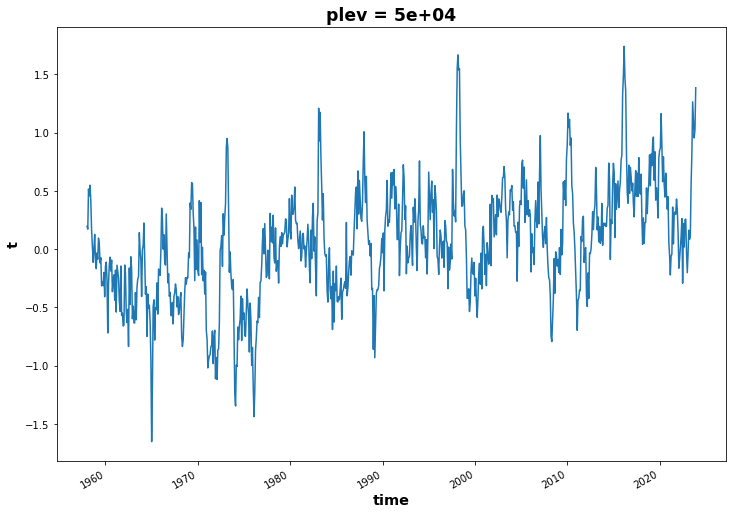

In [111]:
plt.figure(figsize = (12,8))

t500_trop_anom.t.plot()

In [94]:
t2m_anom = (t2m.groupby('time.month') - t2m.groupby('time.month').mean()).sel(time = slice('1958', '2023'))

In [95]:
t2m_anom

<xarray.Dataset>
Dimensions:  (time: 792)
Coordinates:
  * time     (time) datetime64[ns] 1958-01-01 1958-02-01 ... 2023-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    t2m      (time) float64 -0.1588 -0.009722 -0.1258 ... 1.221 1.164 1.178

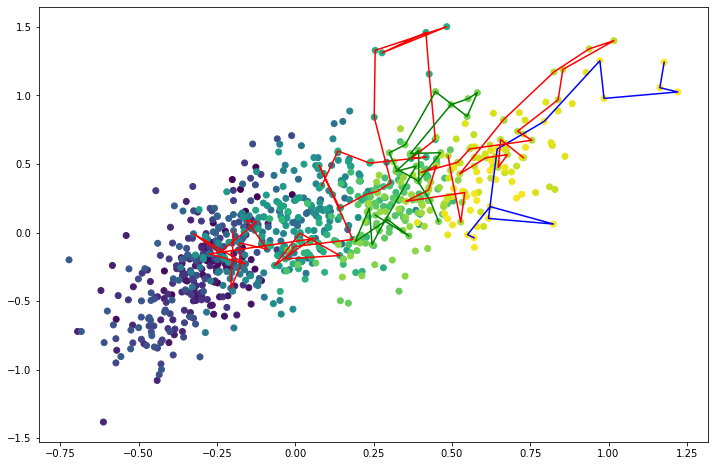

In [100]:
plt.figure(figsize = (12,8))
plt.scatter(t2m_anom.t2m, t500_trop_anom.t, c= t2m_anom.time.dt.year, marker = 'o')
plt.plot(t2m_anom.t2m.sel(time = '2023'), t500_trop_anom.t.sel(time = '2023'), c = 'b')
plt.plot(t2m_anom.t2m.sel(time = slice('2015', '2016')), t500_trop_anom.t.sel(time = slice('2015', '2016')), c = 'r')
plt.plot(t2m_anom.t2m.sel(time = slice('1997', '1998')), t500_trop_anom.t.sel(time = slice('1997', '1998')), c = 'r')
plt.plot(t2m_anom.t2m.sel(time = slice('1982', '1982')), t500_trop_anom.t.sel(time = slice('1982', '1982')), c = 'r')

plt.plot(t2m_anom.t2m.sel(time = slice('2009', '2010')), t500_trop_anom.t.sel(time = slice('2009', '2010')), c = 'g')

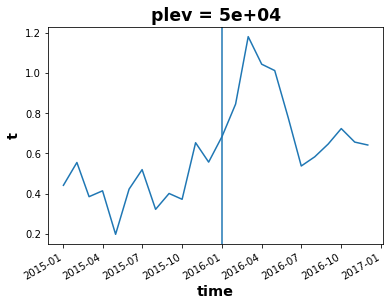

In [181]:
t500_glb_anom.sel(time = slice('2015', '2016')).t.plot()
plt.axvline(x =  np.datetime64('2016'))

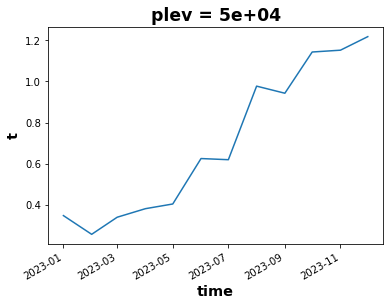

In [182]:
t500_glb_anom.sel(time = slice('2023', '2024')).t.plot()

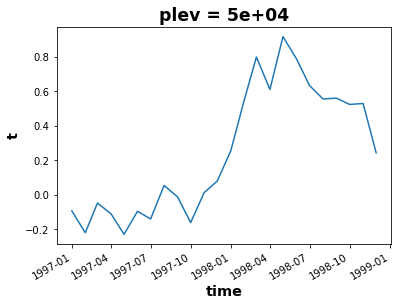

In [183]:
t500_glb_anom.sel(time = slice('1997', '1998')).t.plot()

In [192]:
t500_glb_anom = t500_glb_anom.sel(time = slice('1958', '2023'))

t500_glb_anom

<xarray.Dataset>
Dimensions:  (time: 792, plev: 1)
Coordinates:
  * time     (time) datetime64[ns] 1958-01-01 1958-02-01 ... 2023-12-01
  * plev     (plev) float64 5e+04
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    t        (time, plev) float64 -0.06433 0.1411 0.1736 ... 1.143 1.152 1.218

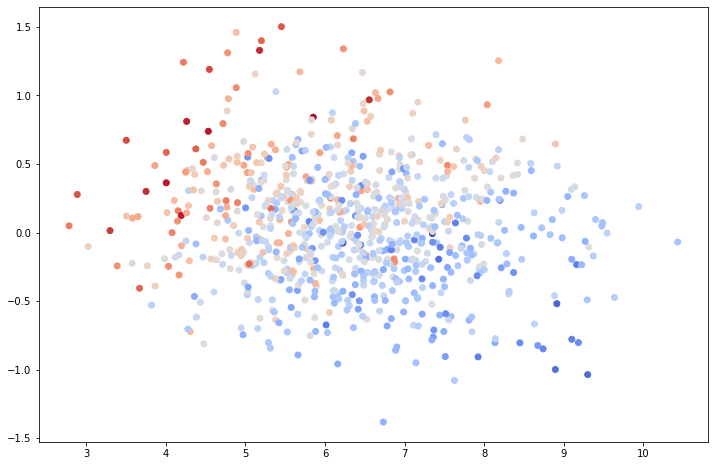

In [196]:
plt.figure(figsize = (12,8))
plt.scatter(tp_west.tp, t500_trop_anom.t, c = nino.nino34, cmap = 'coolwarm')

In [194]:
tp_west = tp_west.sel(time = slice('1958','2023'))

In [197]:
from scipy.stats import linregress

In [225]:
tp_west.tp

<xarray.DataArray 'tp' (time: 792)>
array([ 6.23170891,  5.58793828,  5.51571683,  5.10552598,  5.78862837,
        5.4833485 ,  4.64445685,  6.44301197,  6.02803909,  6.60865207,
        5.04919103,  6.43956983,  5.48359654,  6.85920521,  5.5181774 ,
        6.75148575,  7.57153198,  5.77579299,  4.80087353,  6.38549573,
        6.60730059,  6.61790611,  4.98447997,  5.02188482,  7.26371286,
        7.99324991,  7.93632719,  6.52704919,  5.95931839,  5.75810256,
        7.28540599,  5.95436375,  7.55139104,  5.58655326,  6.12986657,
        6.18578366,  7.82599403,  7.94079378,  7.34289791,  4.7125875 ,
        6.09782283,  6.67649328,  7.22658698,  6.7375632 ,  7.13825751,
        6.4729001 ,  5.65731731,  3.81916928,  6.10464601,  7.40138359,
        8.27995405,  5.86706033,  6.15871603,  6.09873908,  5.28887947,
        7.67069517,  6.28453343,  7.00894181,  5.5253217 ,  6.30561258,
        6.84692136,  7.58296998,  7.44142571,  7.50219223,  7.16226294,
        5.13035182,  6.08946356,  6.60116339,  6.61214279,  5.81020077,
        5.02088582,  3.86378408,  5.55772425,  7.16688223,  7.17735593,
        7.95817989,  5.08332319,  6.93449364,  4.96902234,  4.35787968,
        6.62065974,  5.6531719 ,  5.88145957,  6.88668312,  6.73305844,
        7.62737643,  7.11207009,  7.55352601,  4.47611879,  6.05539144,
        5.37926544,  7.01273222,  4.30524367,  5.85824098,  3.38705834,
        4.16485266,  6.87565276,  6.43716831,  6.18231844,  5.53999282,
...
        4.53261006,  6.55520675,  4.54587487,  5.19996747,  6.23073969,
        5.68150501,  5.83279147,  6.233302  ,  6.93543707,  7.09487451,
        7.80672313,  7.81501533,  6.28885929,  8.58556629,  8.91932469,
        9.09547229,  8.04406382,  7.87960546,  6.15933812,  7.07847374,
        8.48450528,  6.11314777,  7.39449517,  8.18099662,  6.43441336,
        7.47448793,  9.26160914,  6.88363103,  8.08289275,  5.83200049,
        5.45926673,  6.61009066,  8.41858116,  7.97728747,  7.03938886,
        5.07265337,  5.08930219,  7.61664124,  8.1492159 ,  4.89485814,
        7.30226904,  6.07795223,  5.23925579,  7.1012052 ,  6.29001376,
        7.74520628,  5.51966045,  5.39805764,  5.82554027,  4.76991566,
        6.48062001,  6.47011389,  7.16600513,  5.63998813,  6.09174957,
        5.75219594,  6.06923039,  6.38252075,  5.5876404 ,  6.84057039,
        6.47813174,  8.2719607 ,  9.05096944,  9.48914369,  7.23658158,
        7.15271918,  7.02606376,  5.64548714,  8.07150739,  6.34204616,
        6.93780443,  6.01225254,  5.90916739,  8.5923978 ,  7.38186447,
        7.3714423 ,  6.67635166,  8.03592608,  5.16846475,  5.71322413,
        7.9146229 ,  6.00460175,  6.00067569,  6.03044722,  5.63149664,
        8.98110853,  8.82902584,  9.9434568 ,  5.85213942,  6.50560102,
        7.65183996,  6.52919222,  8.18168336,  6.66645895,  6.81678182,
        4.88343739,  4.21969762])
Coordinates:
  * time     (time) datetime64[ns] 1958-01-01 1958-02-01 ... 2023-12-01

In [226]:
slope, inter = linregress(x = nino.nino34, y = tp_west.tp)[:2]

In [228]:
res = tp_west.tp.data - (nino.nino34.data*slope +inter)

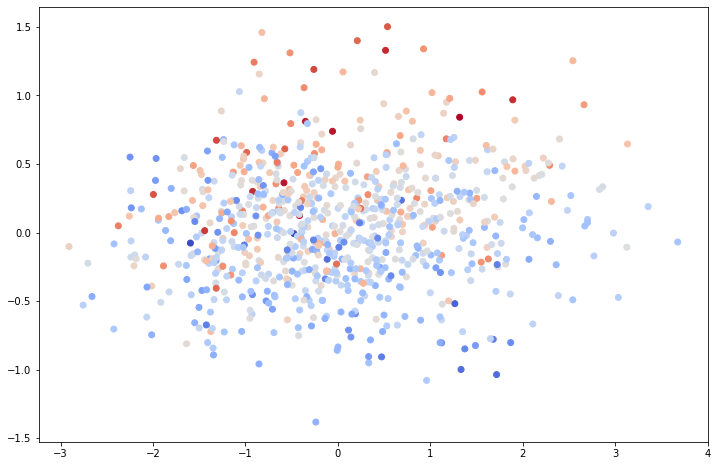

In [230]:
plt.figure(figsize = (12,8))
plt.scatter(res, t500_trop_anom.t, c = nino.nino34, cmap = 'coolwarm')

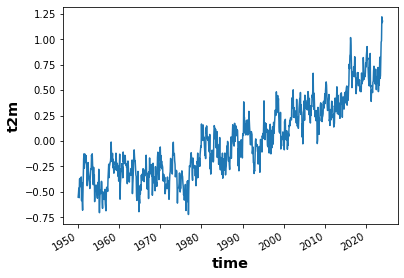

In [235]:
t2m_anom = t2m.groupby('time.month') - t2m.groupby('time.month').mean()
t2m_anom.t2m.plot()

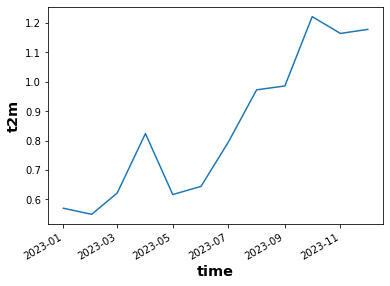

In [237]:
t2m_anom.t2m.sel(time = '2023').plot()


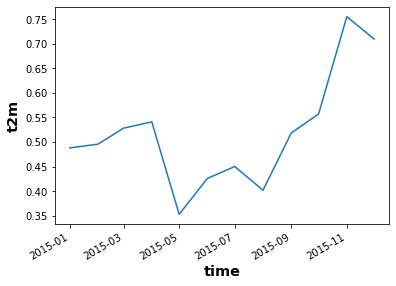

In [238]:
t2m_anom.t2m.sel(time = '2015').plot()
